## 0. Colab setup (skip if running locally)

Colab's VM has its own `/content` filesystem — it does not see this repo's local `data/` folder. When this notebook is opened in Colab, the cell below downloads the dataset directly onto the Colab server via the Kaggle API instead of uploading ~13,000 images from a laptop.

**Before running the next cell:**
1. Rotate your Kaggle API key first: kaggle.com → profile → Settings → API → "Expire API Token", then "Create New Token" to get a fresh username/key.
2. If you're using Colab's own web UI (colab.research.google.com) with the key-icon Secrets panel available, you can add `KAGGLE_USERNAME`/`KAGGLE_KEY` there and the cell will pick them up automatically.
3. **If you're connecting via the Colab VS Code extension** (no Secrets panel available), the cell below falls back to an `input()`/`getpass()` prompt — just paste your username and key when asked. This happens only in the notebook's live output and is never written to the `.ipynb` file, so it's safe even though this notebook is version-controlled.

After the dataset download finishes, upload the three small split files from your local repo (`data/processed/train.csv`, `validation.csv`, `test.csv`) into `/content/data/processed/` using the file explorer of whichever Colab interface you're using (VS Code's Colab extension has its own file browser for the remote `/content` filesystem — these are a few hundred KB, so upload is instant).

**If `Dataset dir exists: False` after running section 2 below:** the Kaggle zip may extract to a differently-named top-level folder than `Garbage_Dataset_Classification`. Run `!ls /content/data/raw` in a scratch cell to see the actual folder name and adjust `DATASET_DIR` in the next section accordingly.

In [1]:
import json
from getpass import getpass
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("Running on Colab:", IN_COLAB)

if IN_COLAB:
    get_ipython().system("pip install -q kaggle")

    kaggle_username = None
    kaggle_key = None

    try:
        from google.colab import userdata
        kaggle_username = userdata.get("KAGGLE_USERNAME")
        kaggle_key = userdata.get("KAGGLE_KEY")
    except Exception:
        pass

    if not kaggle_username or not kaggle_key:
        print("Colab Secrets not available (e.g. connecting via the Colab VS Code extension).")
        print("Enter your Kaggle credentials for this session (not saved to any file):")
        kaggle_username = input("KAGGLE_USERNAME: ").strip()
        kaggle_key = getpass("KAGGLE_KEY: ").strip()

    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_path = kaggle_dir / "kaggle.json"
    kaggle_json_path.write_text(
        json.dumps({"username": kaggle_username, "key": kaggle_key})
    )
    kaggle_json_path.chmod(0o600)

    colab_data_dir = Path("/content/data")
    colab_raw_dir = colab_data_dir / "raw"
    colab_processed_dir = colab_data_dir / "processed"
    colab_raw_dir.mkdir(parents=True, exist_ok=True)
    colab_processed_dir.mkdir(parents=True, exist_ok=True)

    get_ipython().system(
        "kaggle datasets download -d zlatan599/garbage-dataset-classification "
        f"-p {colab_raw_dir} --unzip"
    )

    print()
    print("Dataset downloaded to:", colab_raw_dir)
    print(
        "Now upload data/processed/{train,validation,test}.csv from your local repo "
        f"into: {colab_processed_dir}"
    )

Running on Colab: True
Colab Secrets not available (e.g. connecting via the Colab VS Code extension).
Enter your Kaggle credentials for this session (not saved to any file):
Dataset URL: https://www.kaggle.com/datasets/zlatan599/garbage-dataset-classification
License(s): MIT
100% 121M/121M [00:08<00:00, 15.3MB/s] 


Dataset downloaded to: /content/data/raw
Now upload data/processed/{train,validation,test}.csv from your local repo into: /content/data/processed


In [2]:
import shutil
from pathlib import Path

processed_dir = Path("/content/data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

for name in ("train.csv", "validation.csv", "test.csv"):
    src = Path("/content") / name
    if src.exists():
        shutil.move(str(src), str(processed_dir / name))

print(list(processed_dir.iterdir()))


[PosixPath('/content/data/processed/train.csv'), PosixPath('/content/data/processed/validation.csv'), PosixPath('/content/data/processed/test.csv')]


# 05 — EfficientNetB0 (Member 4)

Transfer-learning model for waste image classification (6 classes).

**Owner:** Member 4
**Approach:** ImageNet-pretrained EfficientNetB0 backbone, frozen head training, then optional fine-tuning of the top backbone layers.

This notebook reuses the exact same dataset split, seed, image size, and batch size as the rest of the group (see `01_EDA_Preprocessing.ipynb`), so results are directly comparable with the Custom CNN, MobileNetV2 and ResNet50 notebooks.

> **Preprocessing note (read before running):** `EfficientNetB0` in `tf.keras.applications` has its own `Rescaling` + `Normalization` layers built in and expects raw pixel values in **[0, 255]**. Unlike the shared EDA notebook (which divides by 255 for the other models), this notebook intentionally skips that division and feeds EfficientNetB0 raw resized pixels. This is a documented, architecture-specific deviation — flag it in the report and in the viva.

In [45]:
from pathlib import Path
import os
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Configuration

Must match the values used by the rest of the group (see `01_EDA_Preprocessing.ipynb`).

In [24]:
RANDOM_SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash",
]
NUM_CLASSES = len(CLASSES)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Random seed:", RANDOM_SEED)

Image size: (224, 224)
Batch size: 32
Number of classes: 6
Random seed: 42


## 2. Paths

In [25]:
PROJECT_ROOT = Path("/content") if IN_COLAB else Path.cwd().parent

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "Garbage_Dataset_Classification"
    / "images"
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
TABLES_DIR = RESULTS_DIR / "tables"

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset dir exists:", DATASET_DIR.exists())
print("Processed dir exists:", PROCESSED_DIR.exists())

Dataset dir exists: True
Processed dir exists: True


## 3. Load the shared train / validation / test split

Same CSVs used by every member — do not regenerate or reshuffle these.

In [26]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
validation_df = pd.read_csv(PROCESSED_DIR / "validation.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

for split_df in (train_df, validation_df, test_df):
    split_df["image_path"] = split_df["relative_path"].apply(
        lambda x: str(DATASET_DIR / x)
    )

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Test images:", len(test_df))

Training images: 9692
Validation images: 2114
Test images: 2091


In [27]:
missing_train = sum(not Path(p).exists() for p in train_df["image_path"])
missing_val = sum(not Path(p).exists() for p in validation_df["image_path"])
missing_test = sum(not Path(p).exists() for p in test_df["image_path"])

print("Missing training images:", missing_train)
print("Missing validation images:", missing_val)
print("Missing test images:", missing_test)

assert missing_train == 0 and missing_val == 0 and missing_test == 0, \
    "Some image files referenced in the split CSVs are missing on disk."


Missing training images: 0
Missing validation images: 0
Missing test images: 0


## 4. Build the `tf.data` pipeline

**No `/255.0` division here** — EfficientNetB0 expects raw [0, 255] pixel values and rescales internally. This is the one deliberate difference from the shared EDA notebook's `load_and_resize_image` function.

In [28]:
def create_dataset(dataframe, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["label"].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_SEED,
            reshuffle_each_iteration=True,
        )

    return dataset


def load_and_resize_image_raw(image_path, label):
    """Load + resize only. Deliberately NOT normalized to [0,1] —
    EfficientNetB0 has its own Rescaling/Normalization layers and
    expects raw [0, 255] pixel values."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)  # stays in [0, 255]
    return image, label

In [30]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="train_augmentation")

# Same augmentation settings as the shared EDA notebook, kept identical
# across members for a fair comparison. Applied to TRAINING data only.

In [31]:
train_dataset = create_dataset(train_df, shuffle=True)
train_dataset = train_dataset.map(load_and_resize_image_raw, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE,
)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

validation_dataset = create_dataset(validation_df, shuffle=False)
validation_dataset = validation_dataset.map(load_and_resize_image_raw, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = create_dataset(test_df, shuffle=False)
test_dataset = test_dataset.map(load_and_resize_image_raw, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Pipelines ready.")

Pipelines ready.


Batch shape: (32, 224, 224, 3)
Min pixel value: 0.0
Max pixel value: 255.0


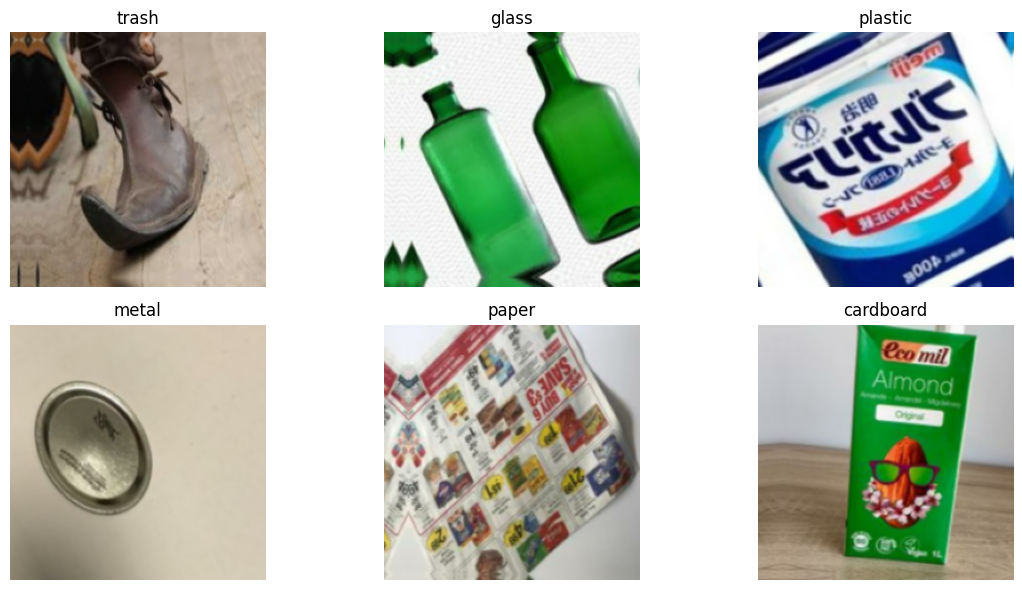

In [32]:
# Sanity check: confirm pixel range is [0, 255] as EfficientNetB0 expects
images, labels = next(iter(train_dataset))
print("Batch shape:", images.shape)
print("Min pixel value:", tf.reduce_min(images).numpy())
print("Max pixel value:", tf.reduce_max(images).numpy())

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASSES[labels[i].numpy()])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Build the model

EfficientNetB0 backbone (ImageNet weights, frozen) → Global Average Pooling → Dropout → Dense(6, softmax).

In [33]:
def build_model(num_classes, image_size, trainable_backbone=False):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=image_size + (3,),
    )
    base_model.trainable = trainable_backbone

    inputs = keras.Input(shape=image_size + (3,))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="efficientnetb0_waste_classifier")
    return model, base_model


model, base_model = build_model(NUM_CLASSES, IMAGE_SIZE, trainable_backbone=False)
model.summary()

Model: "efficientnetb0_waste_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 6. Phase 1 — train the new classification head (backbone frozen)

In [34]:
LR_HEAD = 1e-3
EPOCHS_HEAD = 20

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

head_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "efficientnetb0_head_best.keras"),
        monitor="val_loss",
        save_best_only=True,
    ),
]

start_time = time.time()
history_head = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_HEAD,
    callbacks=head_callbacks,
)
head_train_time = time.time() - start_time

print(f"Phase 1 training time: {head_train_time:.1f} seconds")

Epoch 1/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 191s 555ms/step - accuracy: 0.7396 - loss: 0.7474 - val_accuracy: 0.8472 - val_loss: 0.4690 - learning_rate: 0.0010
Epoch 2/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 145s 478ms/step - accuracy: 0.8454 - loss: 0.4583 - val_accuracy: 0.8751 - val_loss: 0.3907 - learning_rate: 0.0010
Epoch 3/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 145s 479ms/step - accuracy: 0.8537 - loss: 0.4188 - val_accuracy: 0.8742 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 4/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 144s 475ms/step - accuracy: 0.8666 - loss: 0.3822 - val_accuracy: 0.8751 - val_loss: 0.3544 - learning_rate: 0.0010
Epoch 5/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 145s 479ms/step - accuracy: 0.8757 - loss: 0.3658 - val_accuracy: 0.8789 - val_loss: 0.3404 - learning_rate: 0.0010
Epoch 6/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 145s 478ms/step - accuracy: 0.8741 - loss: 0.3544 - val_accuracy: 0.8789 - val_loss: 0.3367 - learning_rate: 0.0010
Epoch 7/20
303/303 ━━━━━━━━━━━━━━━━━━━━ 146s 482ms/step - accura

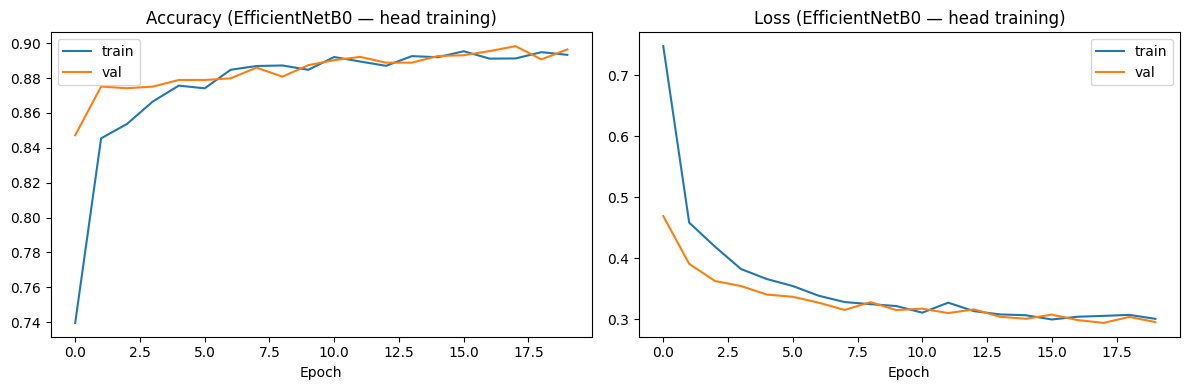

In [35]:
def plot_history(history, title_suffix, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title(f"Accuracy {title_suffix}")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title(f"Loss {title_suffix}")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()


plot_history(
    history_head,
    "(EfficientNetB0 — head training)",
    FIGURES_DIR / "efficientnetb0_history_head.png",
)

## 7. Phase 2 — fine-tune the top of the backbone

Unfreeze the top layers of EfficientNetB0 and continue training with a much smaller learning rate, so the pretrained features aren't destroyed. Set `EPOCHS_FINETUNE = 0` to skip this phase if you want a frozen-only result to compare against.

Epoch 1/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 205s 572ms/step - accuracy: 0.7932 - loss: 0.5803 - val_accuracy: 0.8694 - val_loss: 0.3657
Epoch 2/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 148s 487ms/step - accuracy: 0.8293 - loss: 0.4834 - val_accuracy: 0.8713 - val_loss: 0.3529
Epoch 3/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 148s 489ms/step - accuracy: 0.8383 - loss: 0.4537 - val_accuracy: 0.8798 - val_loss: 0.3357
Epoch 4/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 202s 491ms/step - accuracy: 0.8498 - loss: 0.4140 - val_accuracy: 0.8832 - val_loss: 0.3221
Epoch 5/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 202s 490ms/step - accuracy: 0.8632 - loss: 0.3900 - val_accuracy: 0.8888 - val_loss: 0.3122
Epoch 6/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 149s 491ms/step - accuracy: 0.8710 - loss: 0.3634 - val_accuracy: 0.8903 - val_loss: 0.3039
Epoch 7/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 202s 492ms/step - accuracy: 0.8743 - loss: 0.3554 - val_accuracy: 0.8888 - val_loss: 0.2968
Epoch 8/10
303/303 ━━━━━━━━━━━━━━━━━━━━ 148s 487ms/step - accuracy: 0.8788 -

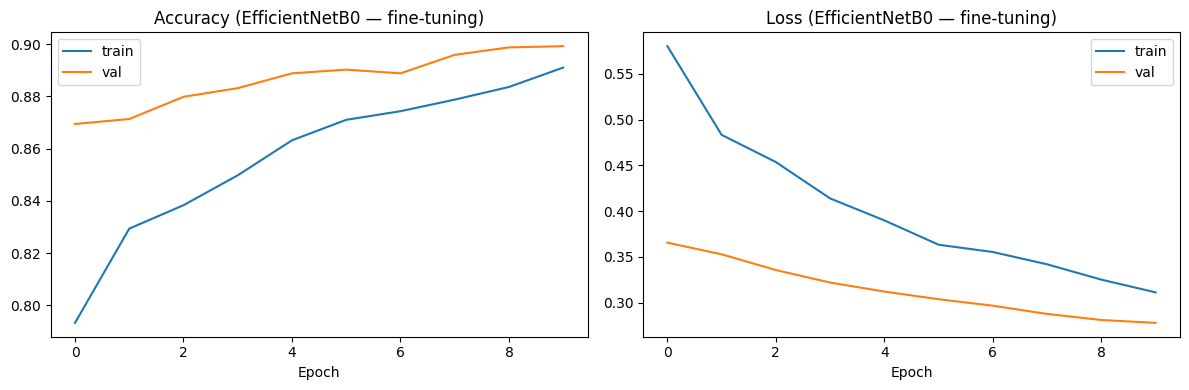

In [36]:
LR_FINETUNE = 1e-5
EPOCHS_FINETUNE = 10
FINE_TUNE_AT_LAYER = -30  # unfreeze this many layers from the end of the backbone

history_finetune = None
finetune_train_time = 0.0

if EPOCHS_FINETUNE > 0:
    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT_LAYER]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    finetune_callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(
            str(MODELS_DIR / "efficientnetb0_finetuned_best.keras"),
            monitor="val_loss",
            save_best_only=True,
        ),
    ]

    start_time = time.time()
    history_finetune = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=EPOCHS_FINETUNE,
        callbacks=finetune_callbacks,
    )
    finetune_train_time = time.time() - start_time

    print(f"Phase 2 (fine-tune) training time: {finetune_train_time:.1f} seconds")

    plot_history(
        history_finetune,
        "(EfficientNetB0 — fine-tuning)",
        FIGURES_DIR / "efficientnetb0_history_finetune.png",
    )
else:
    print("Fine-tuning skipped (EPOCHS_FINETUNE = 0).")

## 8. Final evaluation on the untouched test set

Run this once, after all development/tuning decisions are frozen.

In [46]:
y_true, y_pred, y_probs = [], [], []

for batch_images, batch_labels in test_dataset:
    preds = model.predict(batch_images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(batch_labels.numpy())
    y_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

test_accuracy = accuracy_score(y_true, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)
roc_auc_weighted = roc_auc_score(y_true, y_probs, multi_class="ovr", average="weighted")
report_text = classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Macro precision: {macro_precision:.4f}")
print(f"Macro recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted ROC-AUC: {roc_auc_weighted:.4f}")
print()
print(report_text)

Test accuracy: 0.9106
Macro precision: 0.9107
Macro recall: 0.9110
Macro F1: 0.9100
Weighted ROC-AUC: 0.9909

              precision    recall  f1-score   support

   cardboard       0.88      0.96      0.92       344
       glass       0.96      0.89      0.92       367
       metal       0.86      0.94      0.90       317
       paper       0.92      0.89      0.91       346
     plastic       0.87      0.87      0.87       342
       trash       0.97      0.93      0.95       375

    accuracy                           0.91      2091
   macro avg       0.91      0.91      0.91      2091
weighted avg       0.91      0.91      0.91      2091



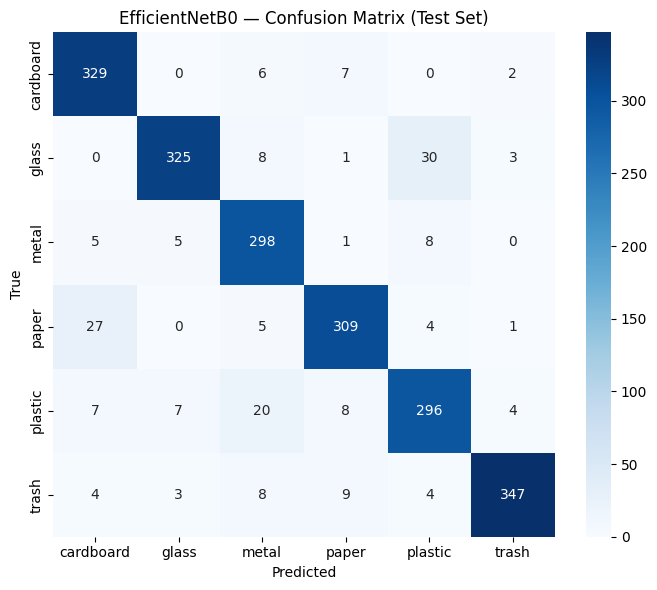

In [47]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNetB0 — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "efficientnetb0_confusion_matrix.png", dpi=150)
plt.show()

## 9. Save results for the group's comparison table

Saved into `results/metrics`, `results/figures`, `results/tables` — the shared locations used by all four members.

In [48]:
total_params = model.count_params()
trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
total_train_time = head_train_time + finetune_train_time

metrics = {
    "model": "EfficientNetB0",
    "member": "Member 4",
    "seed": RANDOM_SEED,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "epochs_head": len(history_head.history["loss"]),
    "epochs_finetune": len(history_finetune.history["loss"]) if history_finetune else 0,
    "lr_head": LR_HEAD,
    "lr_finetune": LR_FINETUNE if EPOCHS_FINETUNE > 0 else None,
    "fine_tune_at_layer": FINE_TUNE_AT_LAYER if EPOCHS_FINETUNE > 0 else None,
    "test_accuracy": float(test_accuracy),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_precision": float(weighted_precision),
    "weighted_recall": float(weighted_recall),
    "weighted_f1": float(weighted_f1),
    "roc_auc_weighted": float(roc_auc_weighted),
    "total_params": int(total_params),
    "trainable_params_final": trainable_params,
    "training_time_seconds": round(total_train_time, 1),
}

METRICS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

with open(METRICS_DIR / "efficientnetb0_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

with open(TABLES_DIR / "efficientnetb0_classification_report.txt", "w") as f:
    f.write(report_text)

pd.DataFrame(cm, index=CLASSES, columns=CLASSES).to_csv(
    TABLES_DIR / "efficientnetb0_confusion_matrix.csv"
)

model.save(MODELS_DIR / "efficientnetb0_final.keras")

print("Saved:")
print(" -", METRICS_DIR / "efficientnetb0_metrics.json")
print(" -", TABLES_DIR / "efficientnetb0_classification_report.txt")
print(" -", TABLES_DIR / "efficientnetb0_confusion_matrix.csv")
print(" -", MODELS_DIR / "efficientnetb0_final.keras")
print()
print(json.dumps(metrics, indent=2))

Saved:
 - /content/results/metrics/efficientnetb0_metrics.json
 - /content/results/tables/efficientnetb0_classification_report.txt
 - /content/results/tables/efficientnetb0_confusion_matrix.csv
 - /content/models/efficientnetb0_final.keras

{
  "model": "EfficientNetB0",
  "member": "Member 4",
  "seed": 42,
  "image_size": [
    224,
    224
  ],
  "batch_size": 32,
  "epochs_head": 20,
  "epochs_finetune": 10,
  "lr_head": 0.001,
  "lr_finetune": 1e-05,
  "fine_tune_at_layer": -30,
  "test_accuracy": 0.9105691056910569,
  "macro_precision": 0.9106555003794724,
  "macro_recall": 0.9109851694329801,
  "macro_f1": 0.9099579457939813,
  "weighted_precision": 0.912722114968371,
  "weighted_recall": 0.9105691056910569,
  "weighted_f1": 0.9107916897275399,
  "roc_auc_weighted": 0.9909464371433455,
  "total_params": 4057257,
  "trainable_params_final": 1503846,
  "training_time_seconds": 4822.1
}


In [49]:
val_accuracies = list(history_head.history["val_accuracy"])
val_losses = list(history_head.history["val_loss"])
if history_finetune is not None:
    val_accuracies += list(history_finetune.history["val_accuracy"])
    val_losses += list(history_finetune.history["val_loss"])

best_val_accuracy = max(val_accuracies)
best_accuracy_epoch = val_accuracies.index(best_val_accuracy) + 1
best_val_loss = min(val_losses)
best_loss_epoch = val_losses.index(best_val_loss) + 1

epochs_trained = metrics["epochs_head"] + metrics["epochs_finetune"]

print("=" * 70)
print("EFFICIENTNETB0 FINAL RESULTS".center(70))
print("=" * 70)
print()
print(f"{'Model':<28}: EfficientNetB0")
print(f"{'Total Parameters':<28}: {total_params:,}")
print(f"{'Trainable Parameters':<28}: {trainable_params:,}")
print(f"{'Non-trainable Parameters':<28}: {total_params - trainable_params:,}")
print()
print("TEST RESULTS")
print("-" * 70)
print(f"{'Accuracy':<28}: {test_accuracy * 100:.2f}%")
print(f"{'Precision (Weighted)':<28}: {weighted_precision * 100:.2f}%")
print(f"{'Recall (Weighted)':<28}: {weighted_recall * 100:.2f}%")
print(f"{'F1-score (Weighted)':<28}: {weighted_f1 * 100:.2f}%")
print(f"{'ROC-AUC (Weighted)':<28}: {roc_auc_weighted * 100:.2f}%")
print()
print("VALIDATION RESULTS")
print("-" * 70)
print(f"{'Best Validation Accuracy':<28}: {best_val_accuracy * 100:.2f}%")
print(f"{'Best Accuracy Epoch':<28}: {best_accuracy_epoch}")
print(f"{'Best Validation Loss':<28}: {best_val_loss:.4f}")
print(f"{'Best Loss Epoch':<28}: {best_loss_epoch}")
print()
print("TRAINING")
print("-" * 70)
print(f"{'Epochs Trained':<28}: {epochs_trained}")
print(f"{'Training Time':<28}: {total_train_time / 60:.2f} minutes")
print("=" * 70)

                     EFFICIENTNETB0 FINAL RESULTS                     

Model                       : EfficientNetB0
Total Parameters            : 4,057,257
Trainable Parameters        : 1,503,846
Non-trainable Parameters    : 2,553,411

TEST RESULTS
----------------------------------------------------------------------
Accuracy                    : 91.06%
Precision (Weighted)        : 91.27%
Recall (Weighted)           : 91.06%
F1-score (Weighted)         : 91.08%
ROC-AUC (Weighted)          : 99.09%

VALIDATION RESULTS
----------------------------------------------------------------------
Best Validation Accuracy    : 89.92%
Best Accuracy Epoch         : 30
Best Validation Loss        : 0.2780
Best Loss Epoch             : 30

TRAINING
----------------------------------------------------------------------
Epochs Trained              : 30
Training Time               : 80.37 minutes


## 10. Error analysis

Pull misclassified test images and look for patterns — required by the assignment's Critical Analysis section and useful for comparing failure modes against the other three models.

In [50]:
misclassified_idx = np.where(y_true != y_pred)[0]
print("Total misclassified:", len(misclassified_idx), "/", len(y_true))

# Confusion pairs, sorted by frequency
from collections import Counter
pairs = Counter(
    (CLASSES[t], CLASSES[p])
    for t, p in zip(y_true[misclassified_idx], y_pred[misclassified_idx])
)
print("\nMost common confusions (true -> predicted):")
for (true_c, pred_c), count in pairs.most_common(10):
    print(f"  {true_c} -> {pred_c}: {count}")

Total misclassified: 187 / 2091

Most common confusions (true -> predicted):
  glass -> plastic: 30
  paper -> cardboard: 27
  plastic -> metal: 20
  trash -> paper: 9
  glass -> metal: 8
  metal -> plastic: 8
  plastic -> paper: 8
  trash -> metal: 8
  cardboard -> paper: 7
  plastic -> glass: 7


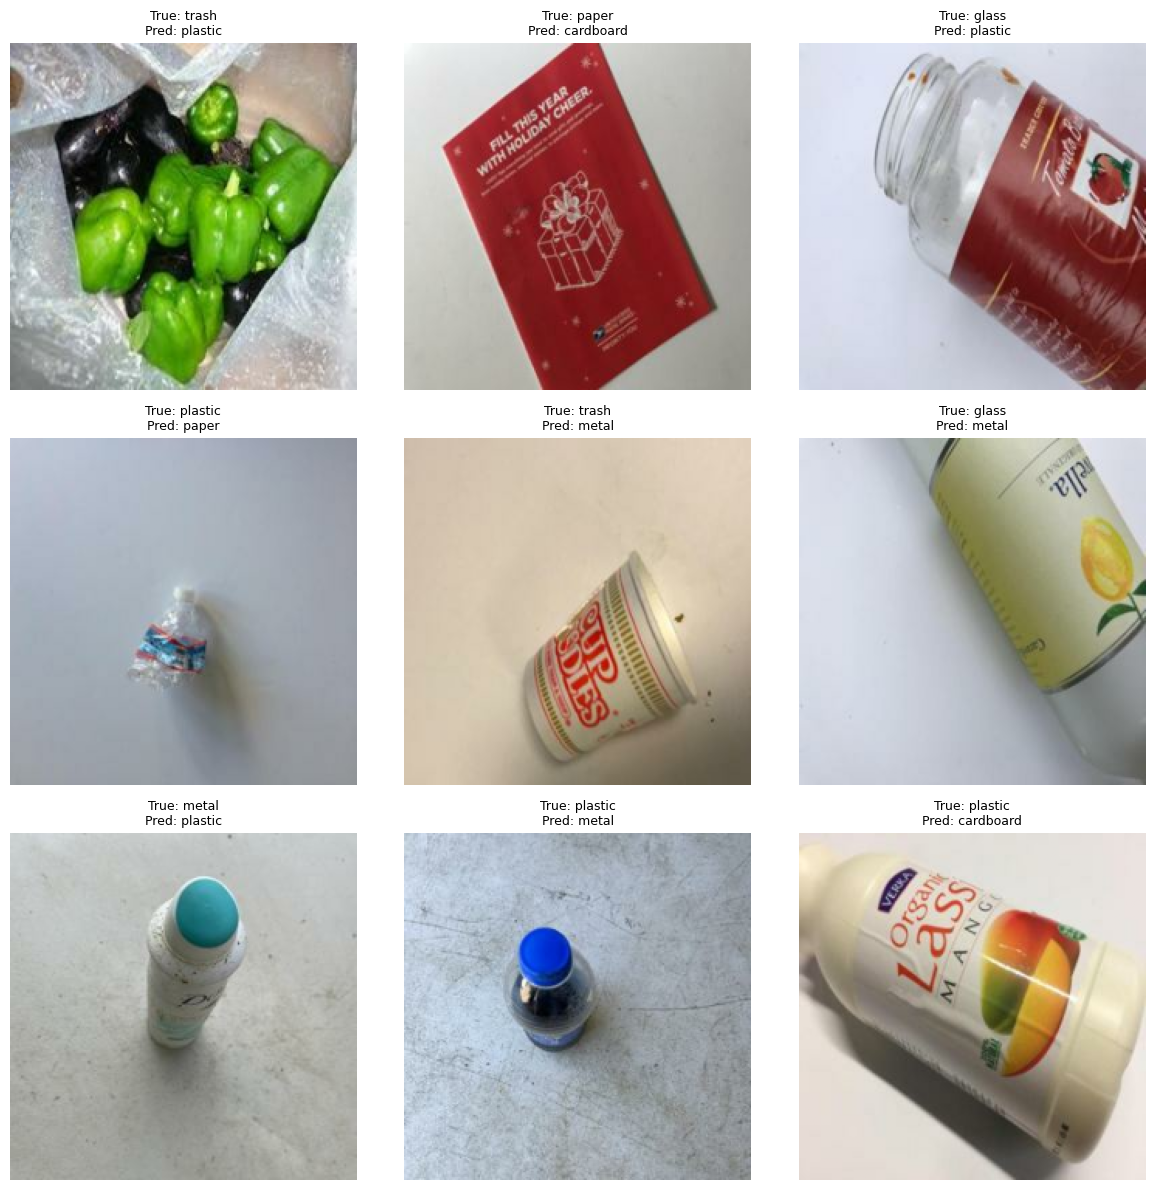

In [41]:
# Visualize a sample of misclassified images
test_df_reset = test_df.reset_index(drop=True)
sample_idx = np.random.RandomState(RANDOM_SEED).choice(
    misclassified_idx, size=min(9, len(misclassified_idx)), replace=False
)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(sample_idx):
    img_path = test_df_reset.loc[idx, "image_path"]
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE) / 255.0  # just for display

    plt.subplot(3, 3, i + 1)
    plt.imshow(img.numpy())
    plt.title(f"True: {CLASSES[y_true[idx]]}\nPred: {CLASSES[y_pred[idx]]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "efficientnetb0_misclassified_examples.png", dpi=150)
plt.show()

## 11. Notes for the report / viva

- **Architecture**: EfficientNetB0 (ImageNet-pretrained) → GlobalAveragePooling2D → Dropout(0.3) → Dense(6, softmax).
- **Two-phase training**: frozen-backbone head training, then fine-tuning of the last `abs(FINE_TUNE_AT_LAYER)` backbone layers at a 100x lower learning rate.
- **Preprocessing deviation (documented)**: unlike the other three models, EfficientNetB0 receives raw [0, 255] pixel input rather than the shared `/255.0` normalization, because it has its own internal `Rescaling`/`Normalization` layers. Same split, seed, image size, batch size, and augmentation policy as the rest of the group are otherwise unchanged.
- **What to discuss**: compound scaling as EfficientNet's core idea vs. ResNet's depth-only and MobileNet's width/efficiency focus; whether fine-tuning improved val/test performance over the frozen-only version; parameter count vs. ResNet50 and MobileNetV2; which classes were most confused and why (cross-reference with the other three members' confusion matrices).